In [2]:
from getpass import getpass

import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [3]:
password = getpass("PostgreSQL password: ")

connection_url = URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password=password,
    host="localhost",
    port=5432,
    database="world",
)

engine = create_engine(connection_url)

PostgreSQL password:  ········


In [4]:
pd.read_sql("SELECT 1 AS test;", engine)

,test
0,1


In [5]:
query = """
SELECT
    c.name AS country,
    COUNT(cl.language) AS official_language_count
FROM country AS c
JOIN countrylanguage AS cl
    ON c.code = cl.countrycode
WHERE cl.isofficial = 'T'
GROUP BY c.name
HAVING COUNT(cl.language) > 2
ORDER BY official_language_count DESC;
"""

In [6]:
df = pd.read_sql(query, engine)

In [7]:
df

,country,official_language_count
0,Switzerland ...,4
1,South Africa ...,4
2,Vanuatu ...,3
3,Belgium ...,3
4,Luxembourg ...,3
5,Peru ...,3
6,Bolivia ...,3
7,Singapore ...,3


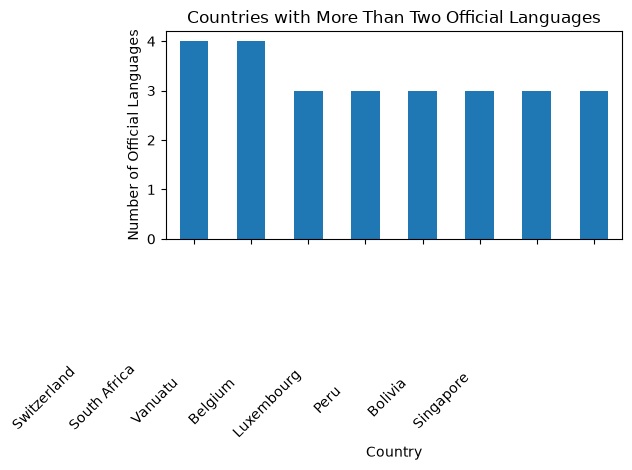

In [8]:
import matplotlib.pyplot as plt

df.plot(kind="bar", x="country", y="official_language_count", legend=False)

plt.xlabel("Country")
plt.ylabel("Number of Official Languages")
plt.title("Countries with More Than Two Official Languages")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [1]:
import os

print(os.getcwd())

C:\Repos\databases-for-analytics
